# Micrograd — Building Backpropagation as a Computation Graph from Scratch

> **Implementation done in Python + NumPy only.** No PyTorch, no TensorFlow, no autograd library.  


---

---
## The `Value` Engine

In [17]:
import math
import random
import numpy as np


class Value:
    """
    A scalar value that lives inside a computation graph.

    Every Value knows:
      - its forward data
      - its accumulated gradient (starts at 0)
      - which Values produced it (_prev)
      - what operation produced it (_op)
      - a _backward closure that knows how to push gradients to _prev
    """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'

    # Arithmetic

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
               # (local derivative of a+b w.r.t. a is 1, same for b)
            self.grad  += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad

        out._backward = _backward
        return out

    def __pow__(self, exponent):
        assert isinstance(exponent, (int, float)), "only scalar exponents supported"
        out = Value(self.data ** exponent, (self,), f'**{exponent}')

        def _backward():
            # Power rule: d/dx x^n = n * x^(n-1)
            self.grad += exponent * (self.data ** (exponent - 1)) * out.grad

        out._backward = _backward
        return out

    def __neg__(self):              return self * -1
    def __sub__(self, other):       return self + (-other)
    def __truediv__(self, other):   return self * other ** -1
    def __radd__(self, other):      return self + other
    def __rmul__(self, other):      return self * other
    def __rsub__(self, other):      return Value(other) + (-self)
    def __rtruediv__(self, other):  return Value(other) * self ** -1

    # Activations

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # d/dx tanh(x) = 1 - tanh²(x)  — the "sech squared" identity
            self.grad += (1.0 - t ** 2) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad

        out._backward = _backward
        return out

# backpropagation

    def backward(self):
        topo    = []
        visited = set()
        stack   = [self]

        while stack:
            v = stack[-1]
            unvisited = [c for c in v._prev if c not in visited]
            if unvisited:
                stack.append(unvisited[0])
            else:
                if v not in visited:
                    visited.add(v)
                    topo.append(v)
                stack.pop()

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [18]:
# Sanity check: compare analytic gradients vs numerical finite differences
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(5.0,  label='c')

d = a * b + c.tanh()
d.backward()

print('Analytic gradients:')
print(f'  a.grad = {a.grad:+.6f}  (should equal b.data = {b.data:+.6f})')
print(f'  b.grad = {b.grad:+.6f}  (should equal a.data = {a.data:+.6f})')

h = 1e-5
def f(a_val, b_val, c_val):
    return Value(a_val) * Value(b_val) + Value(c_val).tanh()

num_a = (f(2+h, -3, 5).data - f(2-h, -3, 5).data) / (2*h)
num_b = (f(2, -3+h, 5).data - f(2, -3-h, 5).data) / (2*h)
num_c = (f(2, -3, 5+h).data - f(2, -3, 5-h).data) / (2*h)

print('\nNumerical gradients:')
print(f'  a.grad ≈ {num_a:+.6f}')
print(f'  b.grad ≈ {num_b:+.6f}')
print(f'  c.grad ≈ {num_c:+.6f}')

print('\nMax error:', max(abs(a.grad - num_a), abs(b.grad - num_b), abs(c.grad - num_c)))

Analytic gradients:
  a.grad = -3.000000  (should equal b.data = -3.000000)
  b.grad = +2.000000  (should equal a.data = +2.000000)

Numerical gradients:
  a.grad ≈ -3.000000
  b.grad ≈ +2.000000
  c.grad ≈ +0.000182

Max error: 6.406208896692078e-11


---
## Section 3 · Graph Visualisation

Let's render the computation graph for $L = \tanh(x \cdot w + b)$ after a backward pass.
Pink circles are operations; blue boxes show each node's scalar value and accumulated gradient.

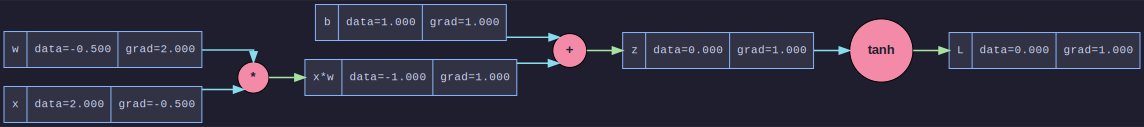

In [19]:
from graphviz import Digraph


def draw_graph(root, rankdir='LR'):
    dot = Digraph(
        format='svg',
        graph_attr={
            'rankdir':  rankdir,
            'bgcolor':  '#1e1e2e',
            'fontname': 'Helvetica',
            'splines':  'ortho',
        }
    )

    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)

    for v in nodes:
        uid  = str(id(v))
        name = f"{v.label} | " if v.label else ""
        dot.node(
            uid,
            label=f"{{ {name}data={v.data:.3f} | grad={v.grad:.3f} }}",
            shape='record',
            style='filled',
            fillcolor='#313244',
            fontcolor='#cdd6f4',
            color='#89b4fa',
            fontname='Courier',
            fontsize='11',
        )
        if v._op:
            op_id = uid + v._op
            dot.node(
                op_id, label=v._op,
                shape='circle',
                style='filled',
                fillcolor='#f38ba8',
                fontcolor='#1e1e2e',
                fontname='Helvetica-Bold',
                fontsize='13',
                width='0.4',
            )
            dot.edge(op_id, uid, color='#a6e3a1', penwidth='1.5')

    for v1, v2 in edges:
        dot.edge(str(id(v1)), str(id(v2)) + v2._op,
                 color='#89dceb', penwidth='1.5')

    return dot


# small example graph
x = Value(2.0,   label='x')
w = Value(-0.5,  label='w')
b = Value(1.0,   label='b')

t = x * w;  t.label = 'x*w'
z = t + b;  z.label = 'z'
L = z.tanh(); L.label = 'L'

L.backward()

draw_graph(L)

In [20]:
print(f'L  = {L.data:.6f},  dL/dL = {L.grad:.6f}')
print(f'z  = {z.data:.6f},  dL/dz = {z.grad:.6f}')
print(f't  = {t.data:.6f},  dL/dt = {t.grad:.6f}')
print(f'x  = {x.data:.6f},  dL/dx = {x.grad:.6f}')
print(f'w  = {w.data:.6f},  dL/dw = {w.grad:.6f}')
print(f'b  = {b.data:.6f},  dL/db = {b.grad:.6f}')

# Manual verification:
# dL/dz = 1 - tanh²(z)
print(f'\nManual dL/dz = 1 - tanh²(z) = {1 - math.tanh(z.data)**2:.6f}')
# dL/dx = dL/dz * w
print(f'Manual dL/dx = dL/dz * w    = {z.grad * w.data:.6f}')
# dL/dw = dL/dz * x
print(f'Manual dL/dw = dL/dz * x    = {z.grad * x.data:.6f}')

L  = 0.000000,  dL/dL = 1.000000
z  = 0.000000,  dL/dz = 1.000000
t  = -1.000000,  dL/dt = 1.000000
x  = 2.000000,  dL/dx = -0.500000
w  = -0.500000,  dL/dw = 2.000000
b  = 1.000000,  dL/db = 1.000000

Manual dL/dz = 1 - tanh²(z) = 1.000000
Manual dL/dx = dL/dz * w    = -0.500000
Manual dL/dw = dL/dz * x    = 2.000000


---
## MLP Built Entirely on `Value`

A `Neuron` is just a dot product + bias + activation, all using `Value` arithmetic.  
A `Layer` is a list of `Neuron`s.  
An `MLP` is a list of `Layer`s.  


In [21]:
class Neuron:
    def __init__(self, n_inputs, activation='relu'):
        scale = (2.0 / n_inputs) ** 0.5
        self.w          = [Value(random.gauss(0, 1) * scale) for _ in range(n_inputs)]
        self.b          = Value(0.0)
        self.activation = activation

    def __call__(self, x):
        pre_act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        if   self.activation == 'tanh': return pre_act.tanh()
        elif self.activation == 'relu': return pre_act.relu()
        return pre_act

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, n_inputs, n_outputs, activation='relu'):
        self.neurons = [Neuron(n_inputs, activation) for _ in range(n_outputs)]

    def __call__(self, x):
        return [neuron(x) for neuron in self.neurons]

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, n_inputs, layer_sizes):
        sizes       = [n_inputs] + layer_sizes
        self.layers = [
            Layer(
                sizes[i], sizes[i + 1],
                activation='relu' if i < len(layer_sizes) - 1 else 'tanh'
            )
            for i in range(len(layer_sizes))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


random.seed(42)
np.random.seed(42)

model = MLP(2, [32, 32, 1])
print(f'Model architecture: 2 → 32 (ReLU) → 32 (ReLU) → 1 (tanh)')
print(f'Total trainable parameters: {len(model.parameters())}')


Model architecture: 2 → 32 (ReLU) → 32 (ReLU) → 1 (tanh)
Total trainable parameters: 1185


---
## Training and Results

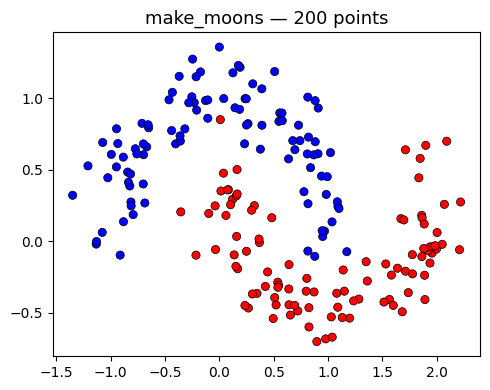

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import make_moons

# Dataset: make_moons
X_np, y_np = make_moons(n_samples=200, noise=0.15, random_state=42)
y_np = y_np * 2 - 1      # {0, 1}  →  {-1, +1}  for hinge loss

plt.figure(figsize=(5, 4))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='bwr',
            edgecolors='k', linewidths=0.5, s=35)
plt.title('make_moons — 200 points', fontsize=13)
plt.tight_layout()
plt.show()


# Helper function: plot decision boundary
def plot_boundary(model, X, y, title, ax):
    h = 0.04
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x0_min, x0_max, h),
        np.arange(x1_min, x1_max, h)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.array([model([float(xi[0]), float(xi[1])]).data for xi in grid])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.75)
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolors='k', linewidths=0.5, s=25)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

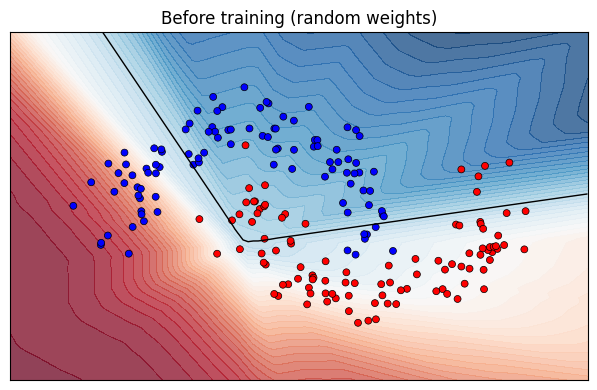

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_boundary(model, X_np, y_np, 'Before training (random weights)', axes[0])
axes[1].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
def total_loss(model, X, y, batch_indices=None):
    if batch_indices is None:
        batch_indices = range(len(X))
    X_b = [X[i] for i in batch_indices]
    y_b = [y[i] for i in batch_indices]
    ypred     = [model([float(xi[0]), float(xi[1])]) for xi in X_b]
    hinge     = [(Value(1.0) - yp * float(yi)).relu() for yi, yp in zip(y_b, ypred)]
    data_loss = sum(hinge, Value(0.0)) * (1.0 / len(hinge))
    return data_loss, ypred, list(y_b)


losses = []
accs   = []
lr     = 0.1
batch_size = 32
n = len(X_np)

for epoch in range(400):
    indices = list(range(n))
    random.shuffle(indices)

    epoch_loss = 0.0
    for start in range(0, n, batch_size):
        batch = indices[start:start + batch_size]
        loss, _, _ = total_loss(model, X_np, y_np, batch)
        model.zero_grad()
        loss.backward()
        for p in model.parameters():
            p.data -= lr * p.grad
        epoch_loss += loss.data

    if epoch % 10 == 0 or epoch == 399:
        _, ypred_full, y_full_list = total_loss(model, X_np, y_np)
        acc = sum(
            (yp.data > 0) == (yi > 0)
            for yp, yi in zip(ypred_full, y_np)
        ) / len(y_np)
        losses.append(epoch_loss)
        accs.append(acc)
        print(f'Epoch {epoch:3d}  |  loss = {epoch_loss:.4f}  |  acc = {acc:.2%}  |  lr = {lr:.5f}')

    if epoch in (150, 250, 330):
        lr *= 0.3

print(f'Final accuracy: {accs[-1]:.2%}')


Epoch   0  |  loss = 4.3196  |  acc = 83.50%  |  lr = 0.10000
Epoch  10  |  loss = 2.0769  |  acc = 85.50%  |  lr = 0.10000
Epoch  20  |  loss = 1.6662  |  acc = 90.50%  |  lr = 0.10000
Epoch  30  |  loss = 1.5459  |  acc = 91.00%  |  lr = 0.10000
Epoch  40  |  loss = 1.3974  |  acc = 91.50%  |  lr = 0.10000
Epoch  50  |  loss = 1.7004  |  acc = 91.50%  |  lr = 0.10000
Epoch  60  |  loss = 1.1166  |  acc = 92.00%  |  lr = 0.10000
Epoch  70  |  loss = 1.1093  |  acc = 91.50%  |  lr = 0.10000
Epoch  80  |  loss = 1.3302  |  acc = 92.00%  |  lr = 0.10000
Epoch  90  |  loss = 1.2399  |  acc = 92.00%  |  lr = 0.10000
Epoch 100  |  loss = 1.2776  |  acc = 92.00%  |  lr = 0.10000
Epoch 110  |  loss = 1.0028  |  acc = 93.00%  |  lr = 0.10000
Epoch 120  |  loss = 0.9449  |  acc = 93.50%  |  lr = 0.10000
Epoch 130  |  loss = 1.2139  |  acc = 93.00%  |  lr = 0.10000
Epoch 140  |  loss = 0.8907  |  acc = 93.50%  |  lr = 0.10000
Epoch 150  |  loss = 1.0579  |  acc = 93.50%  |  lr = 0.10000
Epoch 16

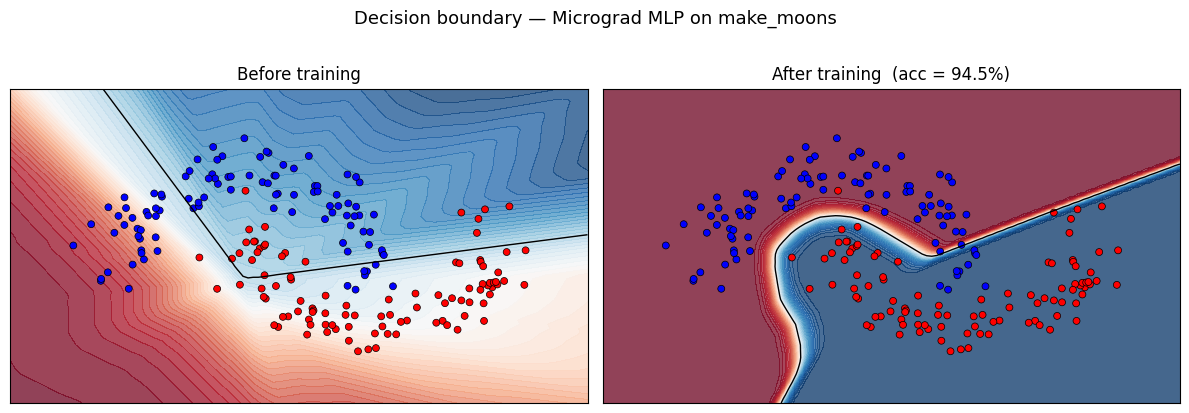

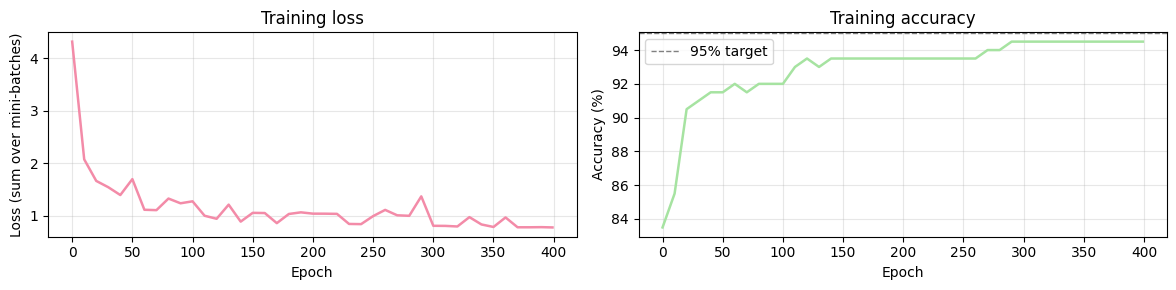

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

random.seed(42)
model_untrained = MLP(2, [32, 32, 1])
plot_boundary(model_untrained, X_np, y_np, 'Before training', axes[0])
plot_boundary(model, X_np, y_np, f'After training  (acc = {accs[-1]:.1%})', axes[1])

plt.suptitle('Decision boundary — Micrograd MLP on make_moons', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# Loss & accuracy curves (evaluated every 10 epochs)
epochs_logged = list(range(0, 400, 10)) + [399]
epochs_logged = sorted(set(epochs_logged))[:len(losses)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

ax1.plot(epochs_logged, losses, color='#f38ba8', linewidth=1.8)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss (sum over mini-batches)')
ax1.set_title('Training loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, [a * 100 for a in accs], color='#a6e3a1', linewidth=1.8)
ax2.axhline(95, color='gray', linestyle='--', linewidth=1, label='95% target')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
